In [1]:
import os, sys, time
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

import os, sys, json
sys.path.append('../../../')
from polygene.model.model import load_trained_model
neural_network_path = "/media/lleger/LaCie/mit/runs/polygene_unit_sphere/"

model, tokenizer = load_trained_model(neural_network_path, checkpoint_n=12)
tokenizer.bypass_inference = True

atlas_path =  "/media/rohola/ssd_storage/lung_cancer_atlas/"
luca_atlas = sc.concat([sc.read_h5ad(atlas_path + file) for file in os.listdir(atlas_path)])

from tqdm import tqdm
from polygene.eval.metrics import prepare_cell

embeddings = np.load('polygene_embeddings.npy')

/home/lleger/miniconda3/envs/gene/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading checkpoint-600000


In [16]:
#gene_expression_euclidean_geodesic 

np.random.seed(4)
luca_atlas.obsm['polygene'] = embeddings
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['lung adenocarcinoma', 'normal'])]
manifold = luca_atlas[luca_atlas.obs['disease'].isin(['squamous cell lung carcinoma', 'normal']) ]#& luca_atlas.obs['cell_type'].isin(['epithelial cell of lung', 'malignant cell'])]
subsample = np.random.choice(np.arange(len(manifold)), size=int(2e4))

manifold = manifold[subsample]
manifold.obsm['X'] = manifold.X.toarray()

start_stage, end_stage = 1, 4
uicc_stages_numerical = manifold.obs['uicc_stage'].apply(lambda x: {'non-cancer': 0, 'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'III or IV': 4}[x]).to_numpy()
healthy_cells = manifold[uicc_stages_numerical == start_stage] 
terminal_cells = manifold[uicc_stages_numerical == end_stage]


from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
def manifold_projection(path, manifold, closest_k=10):
    # function to project a smooth path onto a manifold or set of discrete observations

    # path is a (t, d) array

    # manifold is a (n,d) array
    #distances = cdist(manifold, path) #(t, n) array
    distances = pairwise_distances(manifold, path) #(t, n) array
    closest_point_indices = np.argsort(distances, axis=-1)[:, :closest_k]
    return closest_point_indices

closest_k = 100
number_of_time_points = 100
timepoints = np.linspace(0, 1, num=number_of_time_points)
average_uicc = {}
for coordinate_system in ['X', 'X_umap', 'X_scANVI', 'polygene']:#, 'X_scVI']:

    x_start = healthy_cells.obsm[coordinate_system].mean(axis=0)
    x_end = terminal_cells.obsm[coordinate_system].mean(axis=0)

    geodesic = x_start + timepoints[:, None] * (x_end - x_start)

    manifold_coordinates = manifold.obsm[coordinate_system]

    manifold_indices = manifold_projection(manifold_coordinates, geodesic, closest_k=closest_k)
    average_uicc_stage = [uicc_stages_numerical[indices].mean() for indices in manifold_indices]
    average_uicc[coordinate_system] = average_uicc_stage

/tmp/ipykernel_3414998/1568205761.py:10: ImplicitModificationWarning: Setting element `.obsm['X']` of view, initializing view as actual.
  manifold.obsm['X'] = manifold.X.toarray()


[1.         1.03030303 1.06060606] [1.0, 1.0, 1.0]
[1.         1.03030303 1.06060606] [3.9, 3.9, 3.9]
[1.         1.03030303 1.06060606] [3.72, 3.72, 3.72]
[1.         1.03030303 1.06060606] [1.0, 1.0, 1.0]


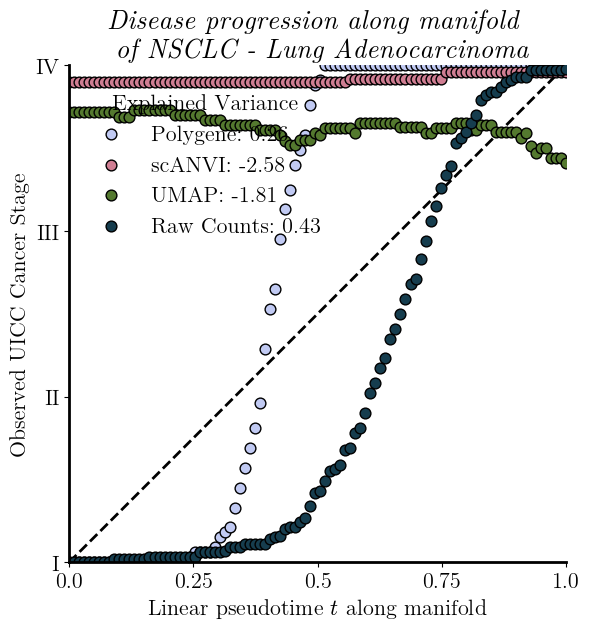

In [18]:
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.metrics import r2_score
plt.rcdefaults()

plt.rcParams['font.family']= 'Latin Modern Roman'
plt.rcParams['mathtext.fontset'] = "cm"

fontsize, dpi = 16, 100
fig, ax = plt.subplots(1, 1, figsize=(6,7), dpi=dpi)
ax.set_aspect('equal')

palette = sns.color_palette('cubehelix_r', n_colors=4)
labels = start_stage + (end_stage-start_stage)*timepoints

for idx, coord in enumerate(list(average_uicc.keys())[::-1]):
    #average, pseudo = average_uicc[coord]
    #print(pseudo)
    print(labels[:3], average_uicc[coord][:3])
    r2 = r2_score(labels, average_uicc[coord])
    #ax.plot(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
    #    'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
    #      color=palette[idx],lw=5, alpha=1, zorder=-1)
    
    ax.scatter(labels, average_uicc[coord], label=coord.replace('X_umap', 'UMAP').replace(
        'X_scANVI', 'scANVI').replace('X', 'Raw Counts').replace('polygene' ,'Polygene') + f': {r2:.2f}',
          color=palette[idx], s=60,lw=1, edgecolors='k')
    

ax.legend(fontsize=fontsize, frameon=False, title=r"Explained Variance", title_fontsize=fontsize, loc="center left", bbox_to_anchor=(0, 0.8))
ax.set_xticks( np.linspace(1, 4, 5), np.linspace(0, 1, 5), fontsize=fontsize)
#ax.set_xticks([0, 1, 2, 3, 4], ["Healthy", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_yticks([0, 1, 2, 3, 4], ["", "I", "II", "III", "IV"], fontsize=fontsize)
ax.set_xlabel(r'Linear pseudotime $t$ along manifold', fontsize=fontsize)
ax.set_ylabel('Observed UICC Cancer Stage', fontsize=fontsize)
ax.plot(labels, labels, lw=2, color="k", zorder=-5, alpha=1, ls='--', label=r"$y=x$")
ax.set_xlim(labels.min(), labels.max())
ax.set_ylim(labels.min(), labels.max())
ax.spines[['top', 'right']].set_linewidth(0)
ax.spines[['bottom', 'left']].set_linewidth(2)
ax.set_title('Disease progression along manifold \n of NSCLC - Lung Adenocarcinoma', fontsize=fontsize*1.2, style='italic')
plt.tight_layout()
#plt.savefig("disease_progression_4.png", dpi=dpi, )#bbox_inches="tight")

# Call it something different than Expected UICC stage. Pseudotime. 
plt.show()